# Confusion Matrix Analysis

This notebook can analyze one or multiple confusion matrices.

Features:

1. Load a confusion matrix from `.xlsx` or from manual input.
2. Support multiple sheets in one workbook.
3. Plot the confusion matrix with `Actual` on the vertical axis and `Predicted` on the horizontal axis.
4. Compute overall metrics and per-class metrics.

Notes:

- The workbook `stat.xlsx` is already configured by default.
- `Sheet1` is excluded by default.
- The label `empty` is treated as the background class in the current workbook.
- The `.xlsx` reader below uses only the Python standard library, so it does not depend on `openpyxl`.


In [17]:
import re
import zipfile
from pathlib import Path
from xml.etree import ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'DejaVu Sans']


In [18]:
# =========================
# Configuration
# =========================

# Choose one: 'excel' or 'manual'
INPUT_MODE = 'excel'

# Default class names used for manual input.
# For labeled Excel sheets, set CLASS_NAMES = None to infer them automatically.
DEFAULT_CLASS_NAMES = [
    'Alternaria alternata',
    'Alternaria tenuissima',
    'Bacillus subtilis',
    'Bacillus thaonhiensis',
    'Deinococcus soli',
    'Kocuria oceani',
    'Arthrobacter oryzae',
    'Micrococcus luteus',
    'Staphylococcus aureus',
    'Streptomyces spororaveus',
    'empty',
]

# If None, labeled Excel sheets will infer class names from the first row/column.
# If you need a custom order, replace None with a full class-name list.
CLASS_NAMES = None

# Excel settings.
EXCEL_PATH = r'E:\CCI-Colony Counting and Identification\CCI\draw\stat.xlsx'

# If None, all sheets except EXCEL_EXCLUDED_SHEETS will be analyzed.
# You can also set it to a single sheet name or a list like ['Y-F', 'Faster'].
EXCEL_SHEET_NAMES = None
EXCEL_EXCLUDED_SHEETS = ['Sheet1']

# Manual input settings.
# Rows = Actual classes, Columns = Predicted classes.
MANUAL_SHEET_NAME = 'manual'
MANUAL_CONFUSION_MATRIX = np.zeros((len(DEFAULT_CLASS_NAMES), len(DEFAULT_CLASS_NAMES)), dtype=float)

FIG_SIZE = (11, 9)
CMAP = 'Blues'
TOP_K_CONFUSIONS = 10


In [19]:
_XML_NS = {
    'main': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main',
    'rel': 'http://schemas.openxmlformats.org/package/2006/relationships',
}
_OFFICE_REL_ATTR = '{http://schemas.openxmlformats.org/officeDocument/2006/relationships}id'
_CELL_REF_RE = re.compile(r'([A-Z]+)(\d+)')


def _clean_labels(labels):
    return [str(label).strip() for label in labels]


def _format_scalar(value):
    value = float(value)
    return str(int(round(value))) if np.isclose(value, round(value)) else f'{value:.4g}'


def _coerce_numeric_dataframe(df, fill_value=0):
    candidate = df.copy()
    candidate = candidate.apply(
        lambda col: col.map(lambda value: np.nan if isinstance(value, str) and not value.strip() else value)
    )
    candidate = candidate.fillna(fill_value)
    numeric_df = candidate.apply(pd.to_numeric, errors='coerce')

    if numeric_df.isna().any().any():
        bad_positions = np.argwhere(numeric_df.isna().to_numpy())
        preview = ', '.join(f'({r + 1}, {c + 1})' for r, c in bad_positions[:5])
        raise ValueError(f'Non-numeric values found in the confusion matrix. Example cells: {preview}')

    return numeric_df


def _excel_col_to_index(col_letters):
    index = 0
    for char in col_letters:
        index = index * 26 + (ord(char) - ord('A') + 1)
    return index - 1


def _parse_xlsx_cell_value(cell, shared_strings):
    cell_type = cell.attrib.get('t')
    value_node = cell.find('main:v', _XML_NS)

    if cell_type == 's':
        if value_node is None or value_node.text is None:
            return None
        return shared_strings[int(value_node.text)]

    if cell_type == 'inlineStr':
        text_nodes = cell.findall('.//main:t', _XML_NS)
        return ''.join(node.text or '' for node in text_nodes)

    if cell_type == 'b':
        return bool(int(value_node.text)) if value_node is not None and value_node.text is not None else None

    if cell_type == 'str':
        return value_node.text if value_node is not None else None

    if value_node is None or value_node.text is None:
        return None

    raw_text = value_node.text
    try:
        numeric_value = float(raw_text)
        return int(numeric_value) if numeric_value.is_integer() else numeric_value
    except ValueError:
        return raw_text


def _load_shared_strings(zip_file):
    try:
        xml_bytes = zip_file.read('xl/sharedStrings.xml')
    except KeyError:
        return []

    root = ET.fromstring(xml_bytes)
    shared_strings = []

    for string_item in root.findall('main:si', _XML_NS):
        text_nodes = string_item.findall('.//main:t', _XML_NS)
        shared_strings.append(''.join(node.text or '' for node in text_nodes))

    return shared_strings


def _load_sheet_targets(zip_file):
    workbook_root = ET.fromstring(zip_file.read('xl/workbook.xml'))
    rel_root = ET.fromstring(zip_file.read('xl/_rels/workbook.xml.rels'))

    rel_map = {
        relation.attrib['Id']: relation.attrib['Target']
        for relation in rel_root.findall('rel:Relationship', _XML_NS)
    }

    ordered_sheet_names = []
    sheet_targets = {}

    for sheet in workbook_root.findall('main:sheets/main:sheet', _XML_NS):
        sheet_name = sheet.attrib['name']
        relation_id = sheet.attrib[_OFFICE_REL_ATTR]
        target = rel_map[relation_id].replace('\\', '/')

        if not target.startswith('xl/'):
            target = f"xl/{target.lstrip('/')}"

        ordered_sheet_names.append(sheet_name)
        sheet_targets[sheet_name] = target

    return ordered_sheet_names, sheet_targets


In [20]:
def list_excel_sheet_names(excel_path):
    path = Path(excel_path)
    if not path.exists():
        raise FileNotFoundError(f'Excel file not found: {path}')

    with zipfile.ZipFile(path, 'r') as zip_file:
        ordered_sheet_names, _ = _load_sheet_targets(zip_file)

    return ordered_sheet_names


def read_excel_sheet_table(excel_path, sheet_name=0):
    path = Path(excel_path)
    if not path.exists():
        raise FileNotFoundError(f'Excel file not found: {path}')

    with zipfile.ZipFile(path, 'r') as zip_file:
        ordered_sheet_names, sheet_targets = _load_sheet_targets(zip_file)

        if isinstance(sheet_name, int):
            if sheet_name < 0 or sheet_name >= len(ordered_sheet_names):
                raise IndexError(f'Sheet index out of range: {sheet_name}')
            resolved_sheet_name = ordered_sheet_names[sheet_name]
        else:
            resolved_sheet_name = str(sheet_name)
            if resolved_sheet_name not in sheet_targets:
                raise KeyError(f'Sheet not found: {resolved_sheet_name}')

        shared_strings = _load_shared_strings(zip_file)
        sheet_xml = zip_file.read(sheet_targets[resolved_sheet_name])

    sheet_root = ET.fromstring(sheet_xml)
    rows = []
    max_row_index = -1
    max_col_index = -1

    for row in sheet_root.findall('.//main:sheetData/main:row', _XML_NS):
        row_index = int(row.attrib.get('r', 1)) - 1
        cell_values = {}

        for cell in row.findall('main:c', _XML_NS):
            cell_ref = cell.attrib.get('r', '')
            match = _CELL_REF_RE.match(cell_ref)
            if not match:
                continue

            col_index = _excel_col_to_index(match.group(1))
            cell_values[col_index] = _parse_xlsx_cell_value(cell, shared_strings)
            max_col_index = max(max_col_index, col_index)

        rows.append((row_index, cell_values))
        max_row_index = max(max_row_index, row_index)

    data = [[None] * (max_col_index + 1) for _ in range(max_row_index + 1)]
    for row_index, cell_values in rows:
        for col_index, value in cell_values.items():
            data[row_index][col_index] = value

    raw_df = pd.DataFrame(data)
    raw_df = raw_df.dropna(axis=0, how='all').dropna(axis=1, how='all')
    return resolved_sheet_name, raw_df


def _resolve_labeled_class_names(class_names, row_labels, col_labels):
    row_labels = _clean_labels(row_labels)
    col_labels = _clean_labels(col_labels)

    if set(row_labels) != set(col_labels):
        raise ValueError('Row labels and column labels do not match.')

    if len(set(row_labels)) != len(row_labels):
        raise ValueError('Duplicate class names found in row labels.')

    if class_names is None:
        return row_labels

    requested = _clean_labels(class_names)
    if set(requested) != set(row_labels):
        raise ValueError('CLASS_NAMES does not match the labels in the Excel sheet.')

    return requested


def validate_confusion_matrix(confusion_matrix, class_names):
    confusion_matrix = np.asarray(confusion_matrix, dtype=float)
    n_classes = len(class_names)

    if confusion_matrix.shape != (n_classes, n_classes):
        raise ValueError(
            f'Confusion matrix shape must be {(n_classes, n_classes)}, '
            f'but got {confusion_matrix.shape}.'
        )

    if not np.isfinite(confusion_matrix).all():
        raise ValueError('Confusion matrix contains NaN or infinite values.')

    if (confusion_matrix < 0).any():
        raise ValueError('Confusion matrix cannot contain negative values.')

    if confusion_matrix.sum() <= 0:
        raise ValueError('Confusion matrix is empty. Fill EXCEL_PATH or MANUAL_CONFUSION_MATRIX first.')

    if np.allclose(confusion_matrix, np.round(confusion_matrix)):
        confusion_matrix = np.round(confusion_matrix).astype(int)

    return confusion_matrix


def load_confusion_matrix_from_excel(excel_path, class_names=None, sheet_name=0, default_class_names=None):
    resolved_sheet_name, raw_df = read_excel_sheet_table(excel_path, sheet_name=sheet_name)

    if raw_df.shape[0] >= 2 and raw_df.shape[1] >= 2:
        row_labels = raw_df.iloc[1:, 0].tolist()
        col_labels = raw_df.iloc[0, 1:].tolist()

        if all(label is not None for label in row_labels) and all(label is not None for label in col_labels):
            resolved_class_names = _resolve_labeled_class_names(class_names, row_labels, col_labels)
            numeric_df = raw_df.iloc[1:, 1:].copy()
            numeric_df.index = _clean_labels(row_labels)
            numeric_df.columns = _clean_labels(col_labels)
            numeric_df = numeric_df.loc[resolved_class_names, resolved_class_names]
            numeric_df = _coerce_numeric_dataframe(numeric_df, fill_value=0)
            cm_array = validate_confusion_matrix(numeric_df.to_numpy(dtype=float), resolved_class_names)
            return resolved_sheet_name, pd.DataFrame(cm_array, index=resolved_class_names, columns=resolved_class_names)

    resolved_class_names = _clean_labels(class_names if class_names is not None else default_class_names)
    if not resolved_class_names:
        raise ValueError('CLASS_NAMES is required for unlabeled numeric matrices.')

    numeric_df = _coerce_numeric_dataframe(raw_df, fill_value=0)
    cm_array = validate_confusion_matrix(numeric_df.to_numpy(dtype=float), resolved_class_names)
    return resolved_sheet_name, pd.DataFrame(cm_array, index=resolved_class_names, columns=resolved_class_names)


def build_confusion_matrices(
    input_mode,
    class_names=None,
    default_class_names=None,
    excel_path=None,
    sheet_names=None,
    excluded_sheets=None,
    manual_matrix=None,
    manual_sheet_name='manual',
):
    input_mode = str(input_mode).strip().lower()

    if input_mode == 'excel':
        if excel_path is None or not str(excel_path).strip():
            raise ValueError('EXCEL_PATH is empty. Fill it or switch INPUT_MODE to "manual".')

        available_sheet_names = list_excel_sheet_names(excel_path)

        if sheet_names is None:
            excluded = set(excluded_sheets or [])
            selected_sheet_names = [name for name in available_sheet_names if name not in excluded]
        elif isinstance(sheet_names, (str, int)):
            selected_sheet_names = [sheet_names]
        else:
            selected_sheet_names = list(sheet_names)

        if not selected_sheet_names:
            raise ValueError('No Excel sheets selected for analysis.')

        matrices = {}
        for selected_sheet_name in selected_sheet_names:
            resolved_sheet_name, cm_df = load_confusion_matrix_from_excel(
                excel_path=excel_path,
                class_names=class_names,
                sheet_name=selected_sheet_name,
                default_class_names=default_class_names,
            )
            matrices[resolved_sheet_name] = cm_df

        return matrices

    if input_mode == 'manual':
        resolved_class_names = _clean_labels(class_names if class_names is not None else default_class_names)
        if not resolved_class_names:
            raise ValueError('CLASS_NAMES is required for manual input.')

        cm_array = validate_confusion_matrix(manual_matrix, resolved_class_names)
        return {
            manual_sheet_name: pd.DataFrame(cm_array, index=resolved_class_names, columns=resolved_class_names)
        }

    raise ValueError('INPUT_MODE must be either "excel" or "manual".')


In [21]:
def _safe_divide(numerator, denominator):
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    result = np.full(np.broadcast(numerator, denominator).shape, np.nan, dtype=float)
    np.divide(numerator, denominator, out=result, where=denominator != 0)
    return result


def _format_cell_value(value, normalize=False):
    if np.isnan(value):
        return 'NA'
    if normalize:
        return f'{value:.1%}'
    if np.isclose(value, round(value)):
        return f'{int(round(value))}'
    return f'{value:.2f}'


def plot_confusion_matrix(confusion_matrix, class_names, normalize=None, figsize=(10, 8), cmap='Blues', title=None):
    confusion_matrix = np.asarray(confusion_matrix, dtype=float)

    if normalize == 'true':
        plot_data = _safe_divide(confusion_matrix, confusion_matrix.sum(axis=1, keepdims=True))
        colorbar_label = 'Ratio'
        default_title = 'Confusion Matrix (Normalized by Actual Class)'
    elif normalize == 'pred':
        plot_data = _safe_divide(confusion_matrix, confusion_matrix.sum(axis=0, keepdims=True))
        colorbar_label = 'Ratio'
        default_title = 'Confusion Matrix (Normalized by Predicted Class)'
    else:
        plot_data = confusion_matrix
        colorbar_label = 'Count'
        default_title = 'Confusion Matrix (Counts)'

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(plot_data, cmap=cmap, aspect='auto')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title or default_title)

    finite_values = plot_data[np.isfinite(plot_data)]
    threshold = 0.0 if finite_values.size == 0 else finite_values.max() / 2

    for i in range(plot_data.shape[0]):
        for j in range(plot_data.shape[1]):
            value = plot_data[i, j]
            text = _format_cell_value(value, normalize=normalize is not None)
            color = 'white' if np.isfinite(value) and value > threshold else 'black'
            ax.text(j, i, text, ha='center', va='center', fontsize=9, color=color)

    ax.set_xlim(-0.5, len(class_names) - 0.5)
    ax.set_ylim(len(class_names) - 0.5, -0.5)
    plt.tight_layout()
    plt.show()


def compute_classification_metrics(confusion_matrix, class_names):
    cm = np.asarray(confusion_matrix, dtype=float)
    total = cm.sum()
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    predicted = cm.sum(axis=0)
    fn = support - tp
    fp = predicted - tp
    tn = total - tp - fp - fn

    precision = _safe_divide(tp, tp + fp)
    recall = _safe_divide(tp, tp + fn)
    specificity = _safe_divide(tn, tn + fp)
    npv = _safe_divide(tn, tn + fn)
    f1_score = _safe_divide(2 * precision * recall, precision + recall)
    iou = _safe_divide(tp, tp + fp + fn)
    fpr = _safe_divide(fp, fp + tn)
    fnr = _safe_divide(fn, fn + tp)
    balanced_accuracy_ovr = (recall + specificity) / 2

    per_class_df = pd.DataFrame(
        {
            'support': support,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'tn': tn,
            'precision': precision,
            'recall': recall,
            'specificity': specificity,
            'npv': npv,
            'f1_score': f1_score,
            'iou': iou,
            'fpr': fpr,
            'fnr': fnr,
            'balanced_accuracy_ovr': balanced_accuracy_ovr,
        },
        index=class_names,
    )

    accuracy = float(tp.sum() / total)
    error_rate = 1.0 - accuracy
    macro_precision = float(np.nanmean(precision))
    macro_recall = float(np.nanmean(recall))
    macro_f1 = float(np.nanmean(f1_score))
    macro_specificity = float(np.nanmean(specificity))
    macro_iou = float(np.nanmean(iou))
    balanced_accuracy = macro_recall
    macro_balanced_accuracy_ovr = float(np.nanmean(balanced_accuracy_ovr))

    weights = support / total
    weighted_precision = float(np.nansum(weights * precision))
    weighted_recall = float(np.nansum(weights * recall))
    weighted_f1 = float(np.nansum(weights * f1_score))
    weighted_iou = float(np.nansum(weights * iou))

    po = accuracy
    pe = float(np.dot(support, predicted) / (total ** 2))
    kappa = np.nan if np.isclose(1 - pe, 0) else (po - pe) / (1 - pe)

    mcc_numerator = float(tp.sum() * total - np.dot(support, predicted))
    mcc_denominator = float(
        np.sqrt((total ** 2 - np.sum(predicted ** 2)) * (total ** 2 - np.sum(support ** 2)))
    )
    mcc = np.nan if np.isclose(mcc_denominator, 0) else mcc_numerator / mcc_denominator

    summary_df = pd.DataFrame(
        {
            'metric': [
                'total_samples',
                'overall_accuracy',
                'error_rate',
                'macro_precision',
                'macro_recall',
                'macro_f1',
                'weighted_precision',
                'weighted_recall',
                'weighted_f1',
                'balanced_accuracy',
                'macro_specificity',
                'macro_balanced_accuracy_ovr',
                'macro_iou',
                'weighted_iou',
                'mcc',
                'cohen_kappa',
            ],
            'value': [
                total,
                accuracy,
                error_rate,
                macro_precision,
                macro_recall,
                macro_f1,
                weighted_precision,
                weighted_recall,
                weighted_f1,
                balanced_accuracy,
                macro_specificity,
                macro_balanced_accuracy_ovr,
                macro_iou,
                weighted_iou,
                mcc,
                kappa,
            ],
        }
    ).set_index('metric')

    return summary_df, per_class_df


def get_top_confusions(confusion_matrix, class_names, top_k=10):
    cm = np.asarray(confusion_matrix, dtype=float)
    row_sums = cm.sum(axis=1)
    records = []

    for actual_idx, actual_name in enumerate(class_names):
        for pred_idx, pred_name in enumerate(class_names):
            if actual_idx == pred_idx:
                continue

            count = cm[actual_idx, pred_idx]
            if count <= 0:
                continue

            row_rate = count / row_sums[actual_idx] if row_sums[actual_idx] > 0 else np.nan
            records.append(
                {
                    'actual': actual_name,
                    'predicted': pred_name,
                    'count': count,
                    'actual_row_rate': row_rate,
                }
            )

    if not records:
        return pd.DataFrame(columns=['actual', 'predicted', 'count', 'actual_row_rate'])

    return pd.DataFrame(records).sort_values(['count', 'actual_row_rate'], ascending=False).head(top_k)


def plot_per_class_metrics(per_class_df, metrics=('Precision', 'Recall', 'f1_score'), figsize=(14, 5), title='Per-Class Metrics'):
    metric_df = per_class_df.loc[:, list(metrics)].copy()
    x = np.arange(len(metric_df.index))
    width = 0.24
    colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756']

    fig, ax = plt.subplots(figsize=figsize)
    center_offset = (len(metric_df.columns) - 1) / 2

    for idx, metric_name in enumerate(metric_df.columns):
        offset = (idx - center_offset) * width
        ax.bar(
            x + offset,
            metric_df[metric_name],
            width=width,
            label=metric_name,
            color=colors[idx % len(colors)],
            edgecolor='black',
            linewidth=0.6,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(metric_df.index, rotation=45, ha='right')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [22]:
cm_results = build_confusion_matrices(
    input_mode=INPUT_MODE,
    class_names=CLASS_NAMES,
    default_class_names=DEFAULT_CLASS_NAMES,
    excel_path=EXCEL_PATH,
    sheet_names=EXCEL_SHEET_NAMES,
    excluded_sheets=EXCEL_EXCLUDED_SHEETS,
    manual_matrix=MANUAL_CONFUSION_MATRIX,
    manual_sheet_name=MANUAL_SHEET_NAME,
)

print(f'Loaded {len(cm_results)} confusion matrices: {list(cm_results.keys())}')

for matrix_name, cm_df in cm_results.items():
    total_samples = cm_df.to_numpy().sum()
    print(f'--- {matrix_name} ---')
    print(f'Shape: {cm_df.shape} | Total samples: {_format_scalar(total_samples)}')
    display(cm_df)


Loaded 4 confusion matrices: ['YOLO-ALL', 'FasterRCNN-ALL', 'YOLO-A', 'FasterRCNN-A']
--- YOLO-ALL ---
Shape: (11, 11) | Total samples: 742


,Alternaria alternata,Alternaria tenuissima,Bacillus subtilis,Bacillus thaonhiensis,Deinococcus soli,Kocuria oceani,Arthrobacter oryzae,Micrococcus luteus,Staphylococcus aureus,Streptomyces spororaveus,empty
Alternaria alternata,18,0,0,0,0,0,0,0,0,0,0
Alternaria tenuissima,0,10,0,0,0,0,0,0,0,0,0
Bacillus subtilis,0,0,17,0,0,0,0,0,0,0,0
Bacillus thaonhiensis,0,0,0,17,0,0,0,0,0,0,1
Deinococcus soli,0,0,0,0,118,0,0,0,0,0,4
Kocuria oceani,0,0,0,0,0,131,0,0,0,0,3
Arthrobacter oryzae,0,0,0,0,0,0,119,0,0,0,33
Micrococcus luteus,0,0,0,0,0,0,0,155,0,0,0
Staphylococcus aureus,0,0,0,0,0,0,0,0,58,0,0
Streptomyces spororaveus,0,0,0,0,0,0,0,0,0,48,0


--- FasterRCNN-ALL ---
Shape: (11, 11) | Total samples: 723


,Alternaria alternata,Alternaria tenuissima,Bacillus subtilis,Bacillus thaonhiensis,Deinococcus soli,Kocuria oceani,Arthrobacter oryzae,Micrococcus luteus,Staphylococcus aureus,Streptomyces spororaveus,empty
Alternaria alternata,18,0,0,0,0,0,0,0,0,0,0
Alternaria tenuissima,0,10,0,0,0,0,0,0,0,0,0
Bacillus subtilis,0,0,17,0,0,0,0,0,0,0,0
Bacillus thaonhiensis,0,0,0,14,0,0,0,0,0,0,2
Deinococcus soli,0,0,0,0,119,0,0,0,0,0,3
Kocuria oceani,0,0,0,0,0,128,0,0,0,0,2
Arthrobacter oryzae,0,0,0,0,0,0,122,0,0,0,22
Micrococcus luteus,0,0,0,0,0,0,0,150,0,0,3
Staphylococcus aureus,0,0,0,0,0,0,0,0,58,0,0
Streptomyces spororaveus,0,0,0,0,0,0,0,0,0,47,1


--- YOLO-A ---
Shape: (11, 11) | Total samples: 711


,Alternaria alternata,Alternaria tenuissima,Bacillus subtilis,Bacillus thaonhiensis,Deinococcus soli,Kocuria oceani,Arthrobacter oryzae,Micrococcus luteus,Staphylococcus aureus,Streptomyces spororaveus,empty
Alternaria alternata,18,0,0,0,0,0,0,0,0,0,0
Alternaria tenuissima,0,10,0,0,0,0,0,0,0,0,0
Bacillus subtilis,0,0,14,0,0,0,0,0,0,0,0
Bacillus thaonhiensis,0,0,0,13,0,0,0,0,0,0,0
Deinococcus soli,0,0,0,0,118,0,0,0,0,0,3
Kocuria oceani,0,0,0,0,0,123,0,0,0,0,0
Arthrobacter oryzae,0,0,0,0,0,0,113,0,0,0,30
Micrococcus luteus,0,0,0,0,0,0,0,154,0,0,0
Staphylococcus aureus,0,0,0,0,0,0,0,0,58,0,0
Streptomyces spororaveus,0,0,0,0,0,0,0,0,0,48,0


--- FasterRCNN-A ---
Shape: (11, 11) | Total samples: 699


,Alternaria alternata,Alternaria tenuissima,Bacillus subtilis,Bacillus thaonhiensis,Deinococcus soli,Kocuria oceani,Arthrobacter oryzae,Micrococcus luteus,Staphylococcus aureus,Streptomyces spororaveus,empty
Alternaria alternata,18,0,0,0,0,0,0,0,0,0,0
Alternaria tenuissima,0,10,0,0,0,0,0,0,0,0,0
Bacillus subtilis,0,0,14,0,0,0,0,0,0,0,0
Bacillus thaonhiensis,0,0,0,13,0,0,0,0,0,0,0
Deinococcus soli,0,0,0,0,119,0,0,0,0,0,1
Kocuria oceani,0,0,0,0,0,123,0,0,0,0,0
Arthrobacter oryzae,0,0,0,0,0,0,122,0,0,0,16
Micrococcus luteus,0,0,0,0,0,0,0,150,0,0,2
Staphylococcus aureus,0,0,0,0,0,0,0,0,58,0,0
Streptomyces spororaveus,0,0,0,0,0,0,0,0,0,47,1


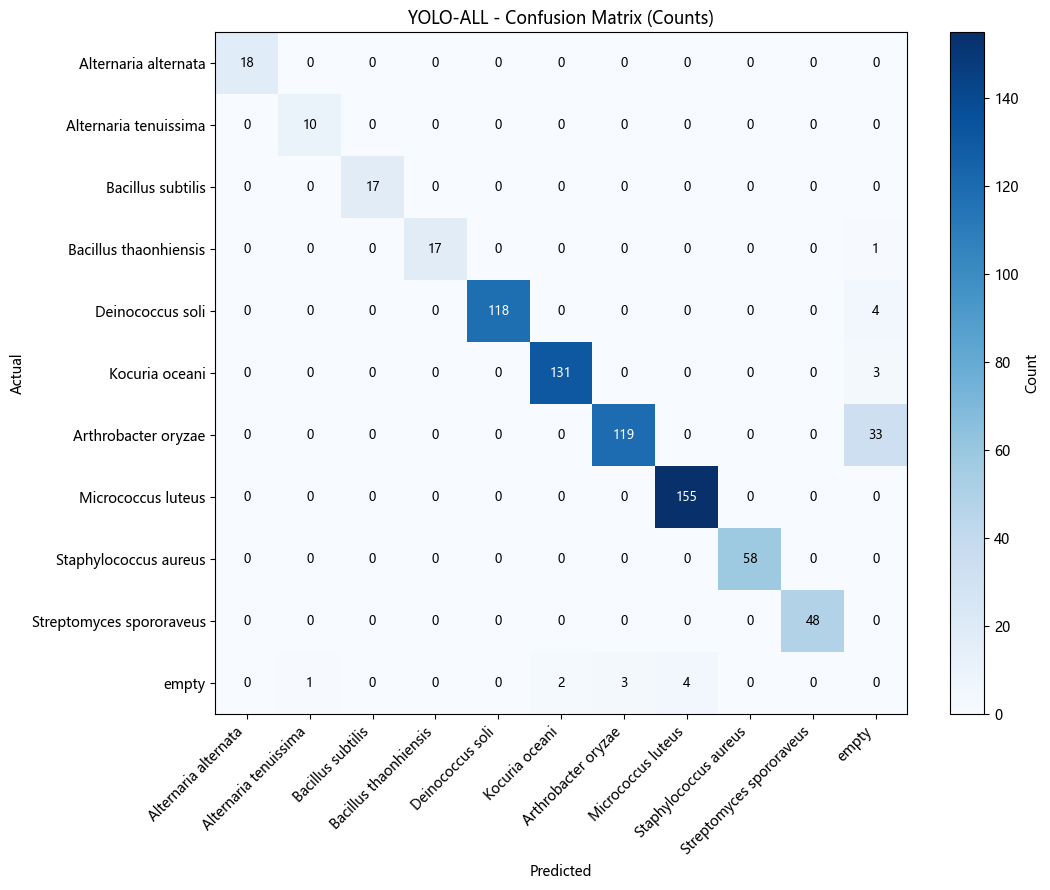

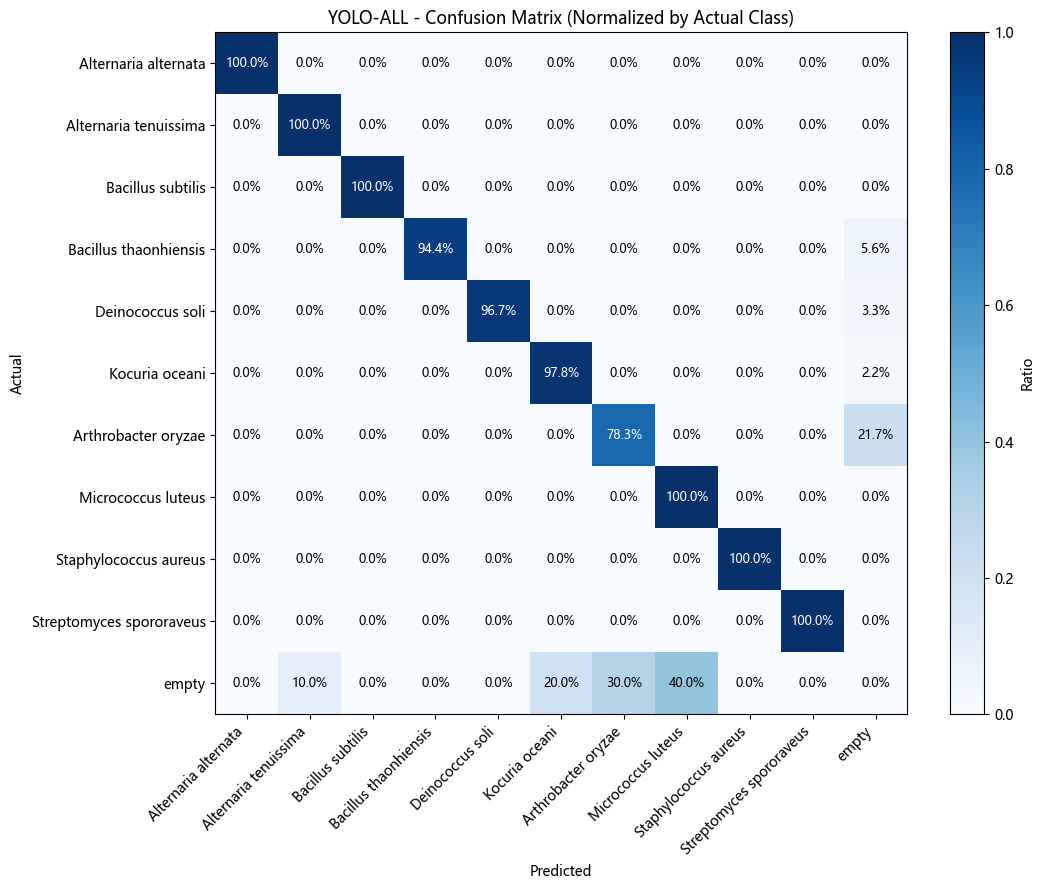

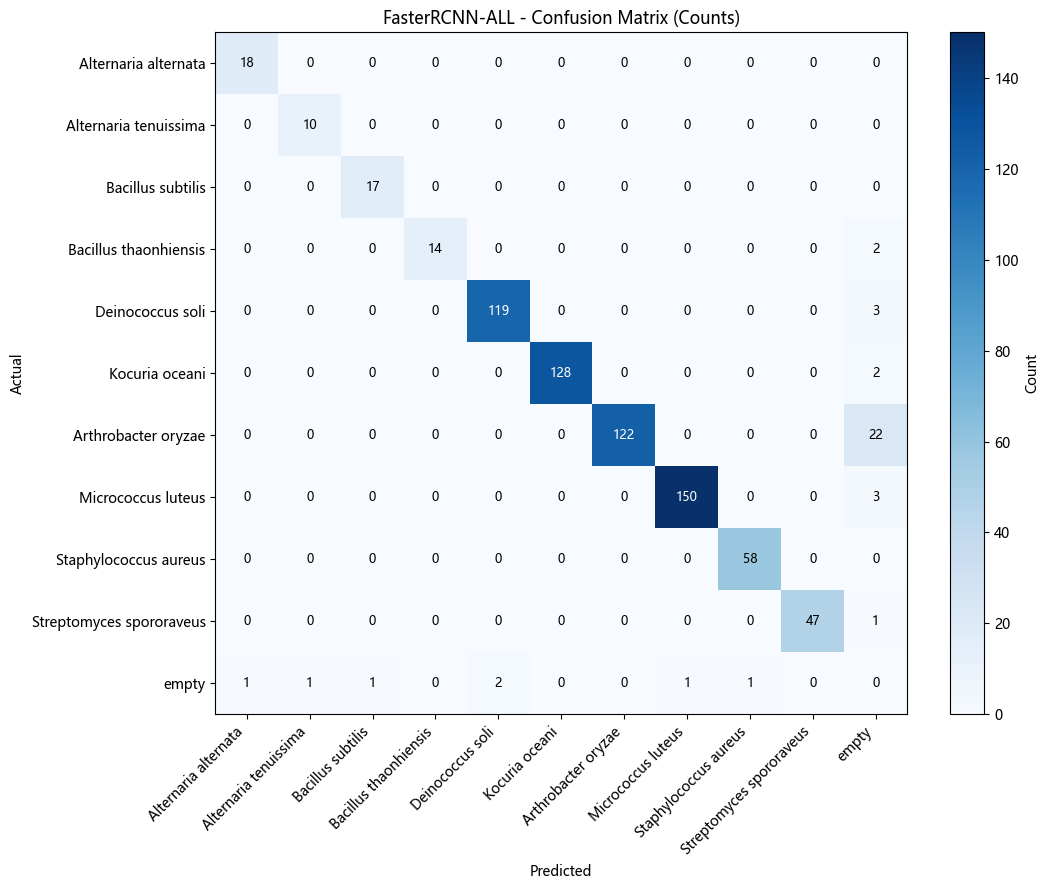

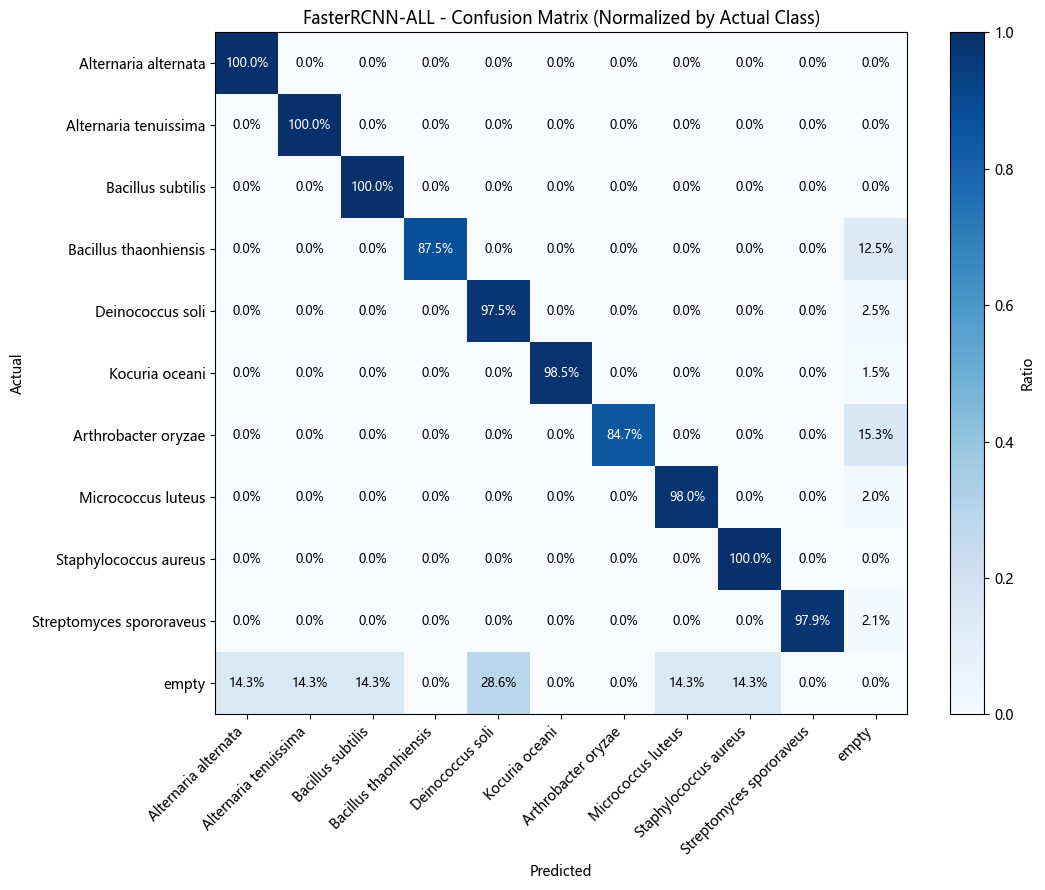

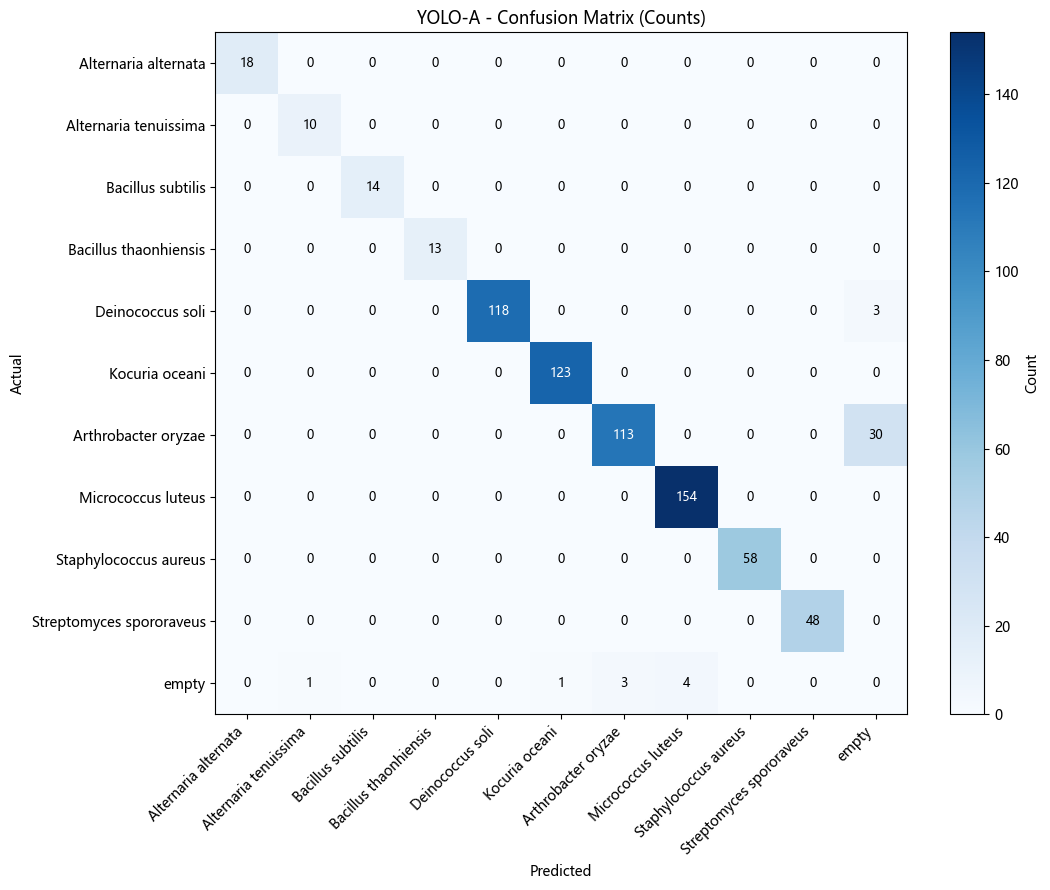

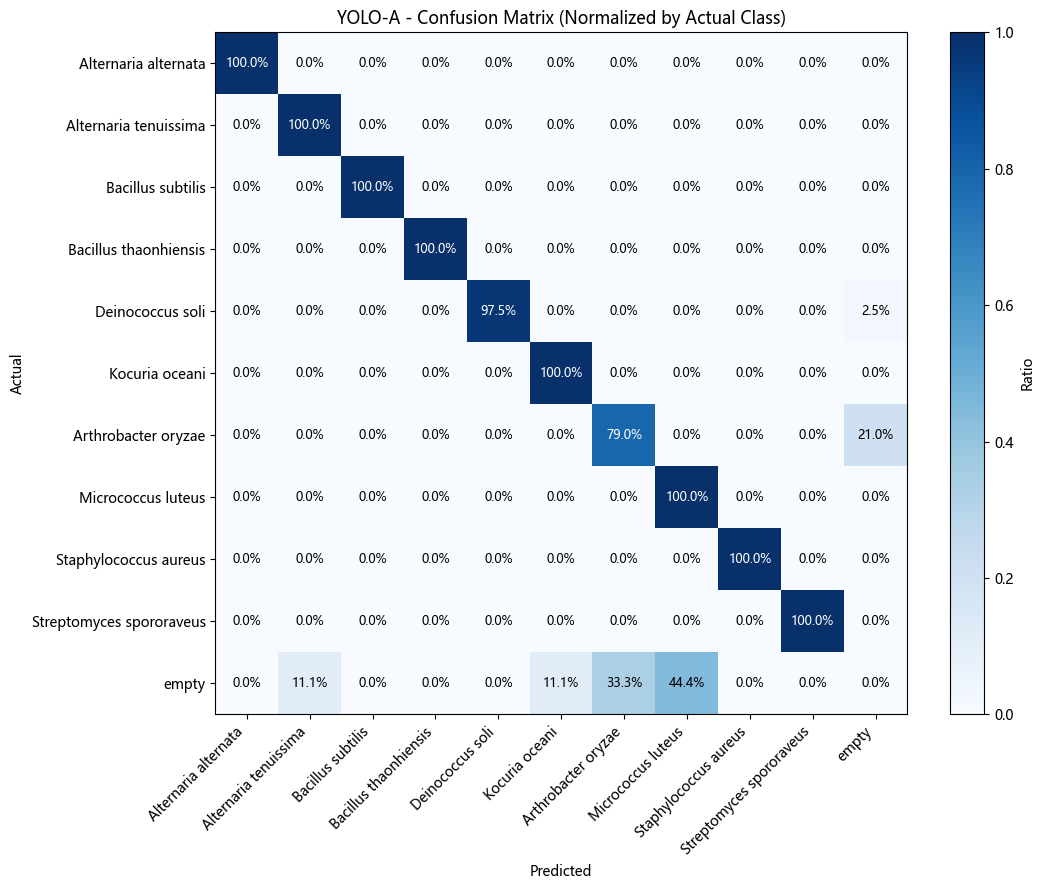

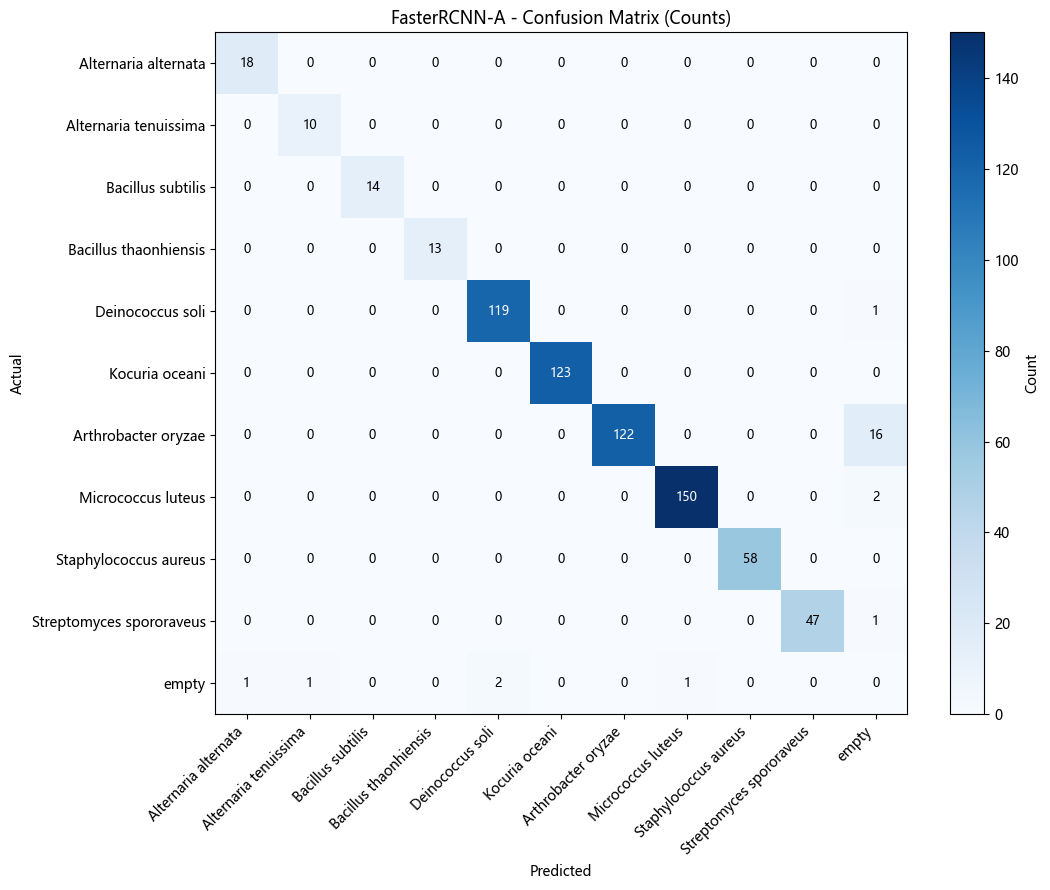

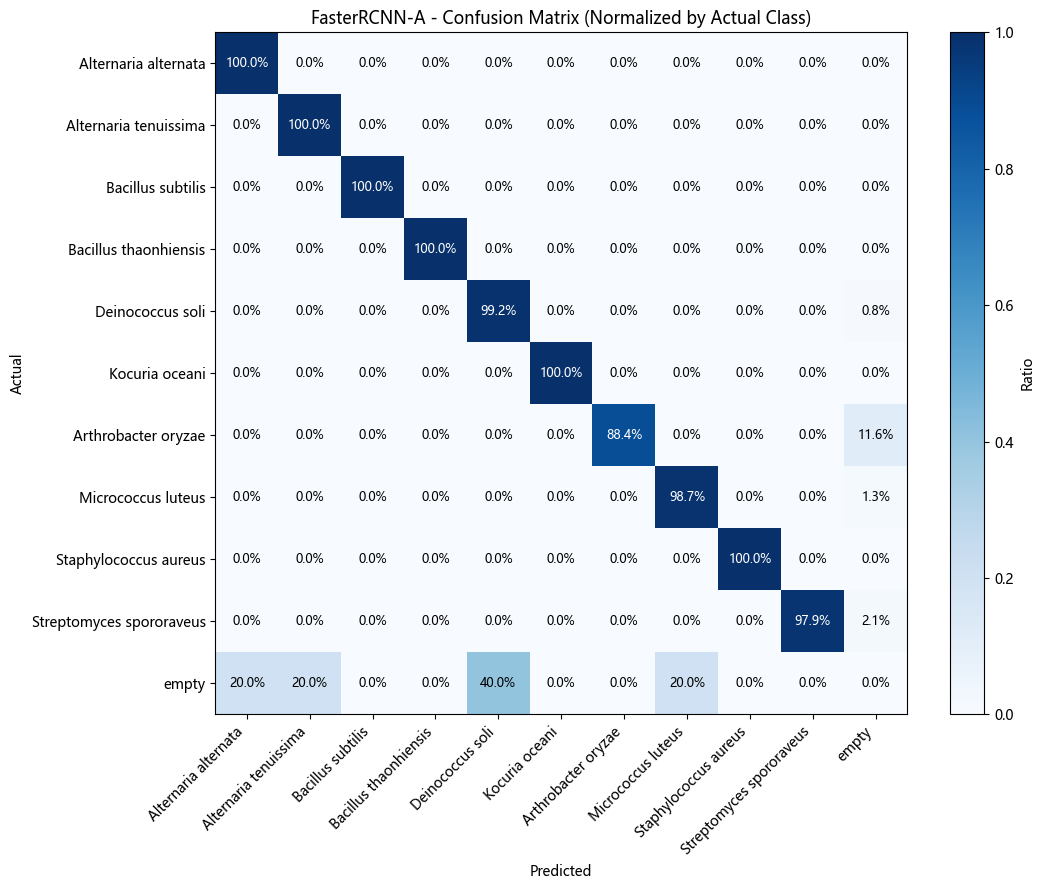

In [23]:
for matrix_name, cm_df in cm_results.items():
    class_names = cm_df.index.tolist()
    plot_confusion_matrix(
        cm_df.to_numpy(),
        class_names,
        normalize=None,
        figsize=FIG_SIZE,
        cmap=CMAP,
        title=f'{matrix_name} - Confusion Matrix (Counts)',
    )
    plot_confusion_matrix(
        cm_df.to_numpy(),
        class_names,
        normalize='true',
        figsize=FIG_SIZE,
        cmap=CMAP,
        title=f'{matrix_name} - Confusion Matrix (Normalized by Actual Class)',
    )


Comparison across matrices:


,total_samples,overall_accuracy,error_rate,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,balanced_accuracy,macro_specificity,macro_balanced_accuracy_ovr,macro_iou,weighted_iou,mcc,cohen_kappa
matrix,,,,,,,,,,,,,,,,
YOLO-ALL,742.0,0.9313,0.0687,0.8949,0.8793,0.9744,0.9723,0.9313,0.9495,0.8793,0.9934,0.9363,0.8661,0.9191,0.9210,0.9191
FasterRCNN-ALL,723.0,0.9447,0.0553,0.8873,0.8765,0.9687,0.9809,0.9447,0.9613,0.8765,0.9948,0.9357,0.8549,0.9354,0.9361,0.9348
YOLO-A,711.0,0.9409,0.0591,0.8954,0.8878,0.9796,0.9740,0.9409,0.9554,0.8878,0.9943,0.9410,0.8750,0.9295,0.9317,0.9303
FasterRCNN-A,699.0,0.9642,0.0358,0.8939,0.8947,0.9831,0.9859,0.9642,0.9743,0.8947,0.9966,0.9457,0.8796,0.9574,0.9582,0.9576


===== YOLO-ALL =====
Overall metrics:


,value
metric,
total_samples,742.0000
overall_accuracy,0.9313
error_rate,0.0687
macro_precision,0.8949
macro_recall,0.8793
macro_f1,0.9744
weighted_precision,0.9723
weighted_recall,0.9313
weighted_f1,0.9495


Per-class metrics:


,support,tp,fp,fn,tn,precision,recall,specificity,npv,f1_score,iou,fpr,fnr,balanced_accuracy_ovr
Alternaria alternata,18.0,18.0,0.0,0.0,724.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000
Alternaria tenuissima,10.0,10.0,1.0,0.0,731.0,0.9091,1.0000,0.9986,1.0000,0.9524,0.9091,0.0014,0.0000,0.9993
Bacillus subtilis,17.0,17.0,0.0,0.0,725.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000
Bacillus thaonhiensis,18.0,17.0,0.0,1.0,724.0,1.0000,0.9444,1.0000,0.9986,0.9714,0.9444,0.0000,0.0556,0.9722
Deinococcus soli,122.0,118.0,0.0,4.0,620.0,1.0000,0.9672,1.0000,0.9936,0.9833,0.9672,0.0000,0.0328,0.9836
Kocuria oceani,134.0,131.0,2.0,3.0,606.0,0.9850,0.9776,0.9967,0.9951,0.9813,0.9632,0.0033,0.0224,0.9872
Arthrobacter oryzae,152.0,119.0,3.0,33.0,587.0,0.9754,0.7829,0.9949,0.9468,0.8686,0.7677,0.0051,0.2171,0.8889
Micrococcus luteus,155.0,155.0,4.0,0.0,583.0,0.9748,1.0000,0.9932,1.0000,0.9873,0.9748,0.0068,0.0000,0.9966
Staphylococcus aureus,58.0,58.0,0.0,0.0,684.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000
Streptomyces spororaveus,48.0,48.0,0.0,0.0,694.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000


Top 8 confusion pairs:


,actual,predicted,count,actual_row_rate
3,Arthrobacter oryzae,empty,33.0,0.2171
7,empty,Micrococcus luteus,4.0,0.4000
1,Deinococcus soli,empty,4.0,0.0328
6,empty,Arthrobacter oryzae,3.0,0.3000
2,Kocuria oceani,empty,3.0,0.0224
5,empty,Kocuria oceani,2.0,0.2000
4,empty,Alternaria tenuissima,1.0,0.1000
0,Bacillus thaonhiensis,empty,1.0,0.0556


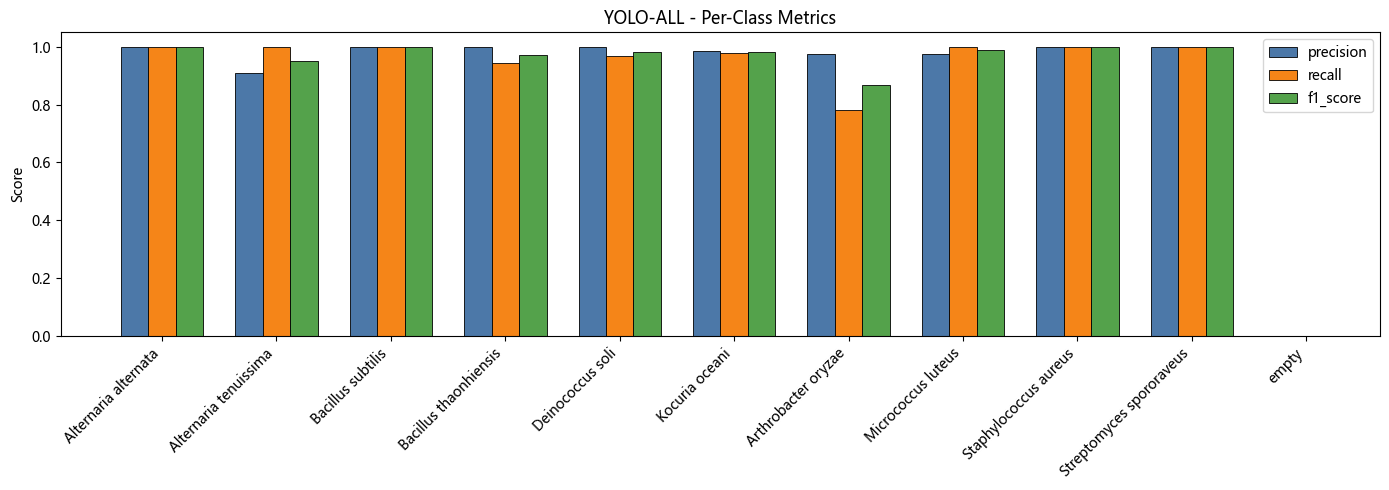

===== FasterRCNN-ALL =====
Overall metrics:


,value
metric,
total_samples,723.0000
overall_accuracy,0.9447
error_rate,0.0553
macro_precision,0.8873
macro_recall,0.8765
macro_f1,0.9687
weighted_precision,0.9809
weighted_recall,0.9447
weighted_f1,0.9613


Per-class metrics:


,support,tp,fp,fn,tn,precision,recall,specificity,npv,f1_score,iou,fpr,fnr,balanced_accuracy_ovr
Alternaria alternata,18.0,18.0,1.0,0.0,704.0,0.9474,1.0000,0.9986,1.0000,0.9730,0.9474,0.0014,0.0000,0.9993
Alternaria tenuissima,10.0,10.0,1.0,0.0,712.0,0.9091,1.0000,0.9986,1.0000,0.9524,0.9091,0.0014,0.0000,0.9993
Bacillus subtilis,17.0,17.0,1.0,0.0,705.0,0.9444,1.0000,0.9986,1.0000,0.9714,0.9444,0.0014,0.0000,0.9993
Bacillus thaonhiensis,16.0,14.0,0.0,2.0,707.0,1.0000,0.8750,1.0000,0.9972,0.9333,0.8750,0.0000,0.1250,0.9375
Deinococcus soli,122.0,119.0,2.0,3.0,599.0,0.9835,0.9754,0.9967,0.9950,0.9794,0.9597,0.0033,0.0246,0.9860
Kocuria oceani,130.0,128.0,0.0,2.0,593.0,1.0000,0.9846,1.0000,0.9966,0.9922,0.9846,0.0000,0.0154,0.9923
Arthrobacter oryzae,144.0,122.0,0.0,22.0,579.0,1.0000,0.8472,1.0000,0.9634,0.9173,0.8472,0.0000,0.1528,0.9236
Micrococcus luteus,153.0,150.0,1.0,3.0,569.0,0.9934,0.9804,0.9982,0.9948,0.9868,0.9740,0.0018,0.0196,0.9893
Staphylococcus aureus,58.0,58.0,1.0,0.0,664.0,0.9831,1.0000,0.9985,1.0000,0.9915,0.9831,0.0015,0.0000,0.9992
Streptomyces spororaveus,48.0,47.0,0.0,1.0,675.0,1.0000,0.9792,1.0000,0.9985,0.9895,0.9792,0.0000,0.0208,0.9896


Top 10 confusion pairs:


,actual,predicted,count,actual_row_rate
3,Arthrobacter oryzae,empty,22.0,0.1528
1,Deinococcus soli,empty,3.0,0.0246
4,Micrococcus luteus,empty,3.0,0.0196
9,empty,Deinococcus soli,2.0,0.2857
0,Bacillus thaonhiensis,empty,2.0,0.1250
2,Kocuria oceani,empty,2.0,0.0154
6,empty,Alternaria alternata,1.0,0.1429
7,empty,Alternaria tenuissima,1.0,0.1429
8,empty,Bacillus subtilis,1.0,0.1429
10,empty,Micrococcus luteus,1.0,0.1429


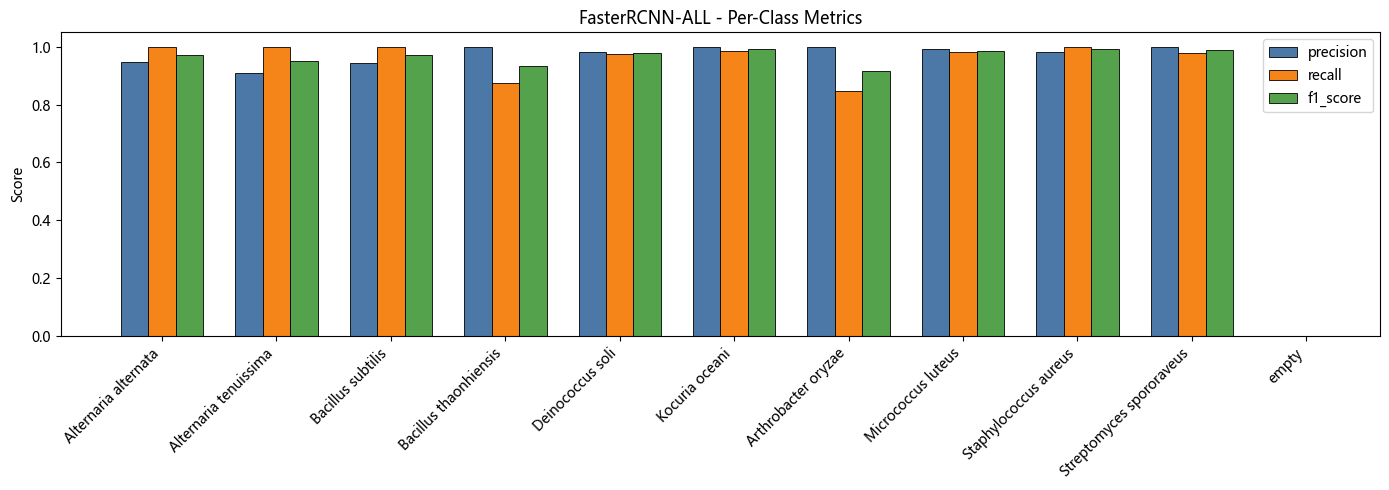

===== YOLO-A =====
Overall metrics:


,value
metric,
total_samples,711.0000
overall_accuracy,0.9409
error_rate,0.0591
macro_precision,0.8954
macro_recall,0.8878
macro_f1,0.9796
weighted_precision,0.9740
weighted_recall,0.9409
weighted_f1,0.9554


Per-class metrics:


,support,tp,fp,fn,tn,precision,recall,specificity,npv,f1_score,iou,fpr,fnr,balanced_accuracy_ovr
Alternaria alternata,18.0,18.0,0.0,0.0,693.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000
Alternaria tenuissima,10.0,10.0,1.0,0.0,700.0,0.9091,1.0000,0.9986,1.0000,0.9524,0.9091,0.0014,0.0000,0.9993
Bacillus subtilis,14.0,14.0,0.0,0.0,697.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000
Bacillus thaonhiensis,13.0,13.0,0.0,0.0,698.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000
Deinococcus soli,121.0,118.0,0.0,3.0,590.0,1.0000,0.9752,1.0000,0.9949,0.9874,0.9752,0.0000,0.0248,0.9876
Kocuria oceani,123.0,123.0,1.0,0.0,587.0,0.9919,1.0000,0.9983,1.0000,0.9960,0.9919,0.0017,0.0000,0.9991
Arthrobacter oryzae,143.0,113.0,3.0,30.0,565.0,0.9741,0.7902,0.9947,0.9496,0.8726,0.7740,0.0053,0.2098,0.8925
Micrococcus luteus,154.0,154.0,4.0,0.0,553.0,0.9747,1.0000,0.9928,1.0000,0.9872,0.9747,0.0072,0.0000,0.9964
Staphylococcus aureus,58.0,58.0,0.0,0.0,653.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000
Streptomyces spororaveus,48.0,48.0,0.0,0.0,663.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000


Top 6 confusion pairs:


,actual,predicted,count,actual_row_rate
1,Arthrobacter oryzae,empty,30.0,0.2098
5,empty,Micrococcus luteus,4.0,0.4444
4,empty,Arthrobacter oryzae,3.0,0.3333
0,Deinococcus soli,empty,3.0,0.0248
2,empty,Alternaria tenuissima,1.0,0.1111
3,empty,Kocuria oceani,1.0,0.1111


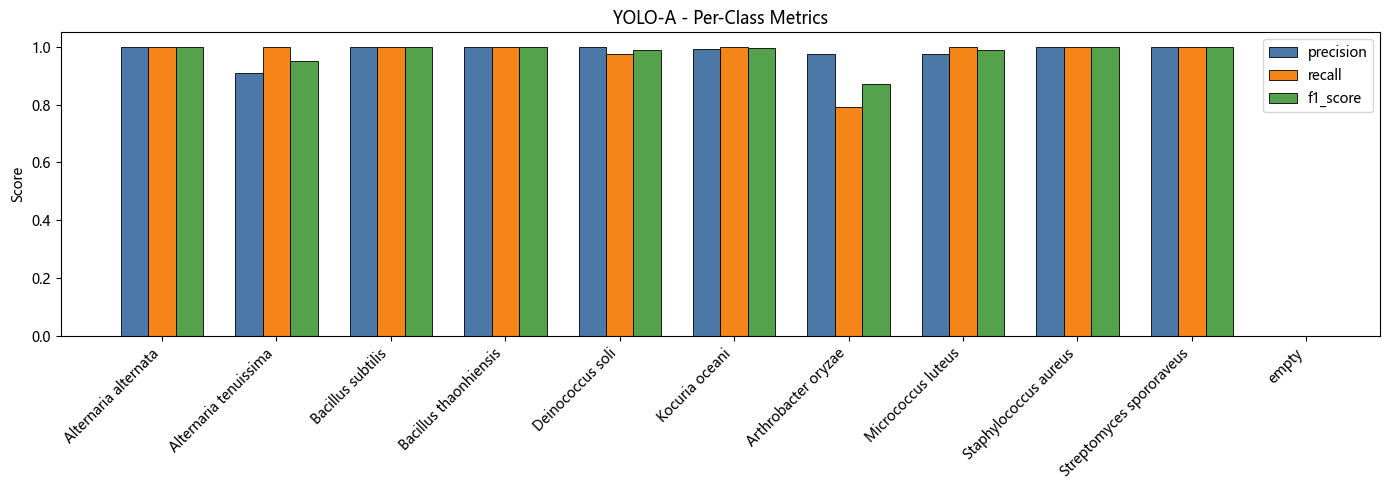

===== FasterRCNN-A =====
Overall metrics:


,value
metric,
total_samples,699.0000
overall_accuracy,0.9642
error_rate,0.0358
macro_precision,0.8939
macro_recall,0.8947
macro_f1,0.9831
weighted_precision,0.9859
weighted_recall,0.9642
weighted_f1,0.9743


Per-class metrics:


,support,tp,fp,fn,tn,precision,recall,specificity,npv,f1_score,iou,fpr,fnr,balanced_accuracy_ovr
Alternaria alternata,18.0,18.0,1.0,0.0,680.0,0.9474,1.0000,0.9985,1.0000,0.9730,0.9474,0.0015,0.0000,0.9993
Alternaria tenuissima,10.0,10.0,1.0,0.0,688.0,0.9091,1.0000,0.9985,1.0000,0.9524,0.9091,0.0015,0.0000,0.9993
Bacillus subtilis,14.0,14.0,0.0,0.0,685.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000
Bacillus thaonhiensis,13.0,13.0,0.0,0.0,686.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000
Deinococcus soli,120.0,119.0,2.0,1.0,577.0,0.9835,0.9917,0.9965,0.9983,0.9876,0.9754,0.0035,0.0083,0.9941
Kocuria oceani,123.0,123.0,0.0,0.0,576.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000
Arthrobacter oryzae,138.0,122.0,0.0,16.0,561.0,1.0000,0.8841,1.0000,0.9723,0.9385,0.8841,0.0000,0.1159,0.9420
Micrococcus luteus,152.0,150.0,1.0,2.0,546.0,0.9934,0.9868,0.9982,0.9964,0.9901,0.9804,0.0018,0.0132,0.9925
Staphylococcus aureus,58.0,58.0,0.0,0.0,641.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000
Streptomyces spororaveus,48.0,47.0,0.0,1.0,651.0,1.0000,0.9792,1.0000,0.9985,0.9895,0.9792,0.0000,0.0208,0.9896


Top 8 confusion pairs:


,actual,predicted,count,actual_row_rate
1,Arthrobacter oryzae,empty,16.0,0.1159
6,empty,Deinococcus soli,2.0,0.4000
2,Micrococcus luteus,empty,2.0,0.0132
4,empty,Alternaria alternata,1.0,0.2000
5,empty,Alternaria tenuissima,1.0,0.2000
7,empty,Micrococcus luteus,1.0,0.2000
3,Streptomyces spororaveus,empty,1.0,0.0208
0,Deinococcus soli,empty,1.0,0.0083


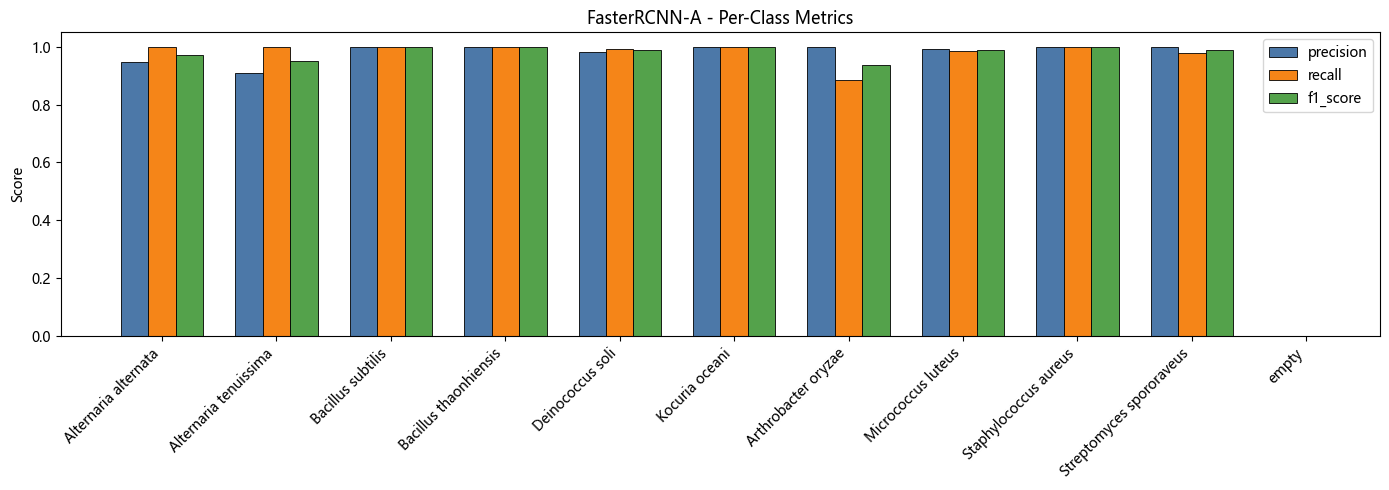

In [24]:
comparison_records = []
analysis_results = {}

for matrix_name, cm_df in cm_results.items():
    class_names = cm_df.index.tolist()
    summary_metrics_df, per_class_metrics_df = compute_classification_metrics(cm_df.to_numpy(), class_names)
    top_confusions_df = get_top_confusions(cm_df.to_numpy(), class_names, top_k=TOP_K_CONFUSIONS)

    comparison_record = {'matrix': matrix_name}
    comparison_record.update(summary_metrics_df['value'].to_dict())
    comparison_records.append(comparison_record)

    analysis_results[matrix_name] = {
        'summary': summary_metrics_df,
        'per_class': per_class_metrics_df,
        'top_confusions': top_confusions_df,
    }

comparison_df = pd.DataFrame(comparison_records).set_index('matrix')
print('Comparison across matrices:')
display(comparison_df.round(4))

for matrix_name, result in analysis_results.items():
    top_confusions_df = result['top_confusions']
    print(f'===== {matrix_name} =====')
    print('Overall metrics:')
    display(result['summary'].round(4))

    print('Per-class metrics:')
    display(result['per_class'].round(4))

    if top_confusions_df.empty:
        print('No off-diagonal errors found in the confusion matrix.')
    else:
        print(f'Top {len(top_confusions_df)} confusion pairs:')
        display(top_confusions_df.round(4))

    plot_per_class_metrics(
        result['per_class'],
        metrics=('precision', 'recall', 'f1_score'),
        title=f'{matrix_name} - Per-Class Metrics',
    )
